In [1]:
import pandas as pd
import numpy as np
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
matplotlib.rcParams['pdf.fonttype'] = 42
import sklearn
from sklearn import linear_model
import seaborn as sns
sns.set_context('talk')
sns.set_style('white')
sns.set_style('ticks')

%matplotlib inline

In [3]:
def bayes_cov_col(Y,X,cols,lm):
    """
    @Y    = Expression matrix, cells x x genes, expecting pandas dataframe
    @X    = Covariate matrix, cells x covariates, expecting pandas dataframe
    @cols = The subset of columns that the EM should be performed over, expecting list
    @lm   = linear model object
    """

    #EM iterateit
    Yhat=pd.DataFrame(lm.predict(X))
    Yhat.index=Y.index
    Yhat.columns=Y.columns
    SSE_all=np.square(Y.subtract(Yhat))
    X_adjust=X.copy()


    df_SSE   = []
    df_logit = []

    for curcov in cols:

        curcells=X[X[curcov]>0].index

        if len(curcells)>2:

            X_notcur=X.copy()
            X_notcur[curcov]=[0]*len(X_notcur)

            X_sub=X_notcur.loc[curcells]

            Y_sub=Y.loc[curcells]

            GENE_var=2.0*Y_sub.var(axis=0)
            vargenes=GENE_var[GENE_var>0].index

            Yhat_notcur=pd.DataFrame(lm.predict(X_sub))
            Yhat_notcur.index=Y_sub.index
            Yhat_notcur.columns=Y_sub.columns

            SSE_notcur=np.square(Y_sub.subtract(Yhat_notcur))
            SSE=SSE_all.loc[curcells].subtract(SSE_notcur)
            SSE_sum=SSE.sum(axis=1)

            SSE_transform=SSE.div(GENE_var+0.5)[vargenes].sum(axis=1)
            logitify=np.divide(1.0,1.0+np.exp(SSE_transform))#sum))

            df_SSE.append(SSE_sum)
            df_logit.append(logitify)

            X_adjust[curcov].loc[curcells]=logitify

    return X_adjust

100

In [5]:
#simulate two multivariate normal distributions for two classes
#initial parameters
ncells=1000
ngenes=200
halfcells=int(ncells/2.0)
tenthcells=int(ncells/10.0)
informativegenes=0.1
effectsize=1.0
#Simulate Class 0 cells
y1=pd.DataFrame(np.random.normal(loc=0,scale=1,size=(halfcells,int(informativegenes*ngenes))))

#Simulate Class 1 cells
y2=pd.DataFrame(np.random.normal(loc=effectsize,scale=1,size=(halfcells,int(informativegenes*ngenes))))

#Noisy genes
y3=pd.DataFrame(np.random.normal(loc=0,scale=1,size=(ncells,int(ngenes*(1.0-informativegenes)))))

#Concatenate to form cells x genes expression matrix
Y=pd.concat([y1,y2]).reset_index(drop=True)
Y=pd.concat([Y,y3],axis=1)
Y.columns=range(np.shape(Y)[1])
Y.head()

,0,1,2,3,4,5,6,7,8,9,...,190,191,192,193,194,195,196,197,198,199
0,0.442097,-1.532915,1.241990,0.627739,-1.576347,0.596201,1.411059,-1.195229,-1.429009,0.368926,...,0.223527,0.202057,-0.104562,0.249295,0.635993,-0.792595,-1.270357,-1.772272,-2.206742,-1.119149
1,0.231768,0.862954,-0.645632,-2.313602,-0.362704,0.113340,1.029408,0.292075,-0.949639,0.688851,...,0.399182,-0.396198,0.198960,-0.151946,0.772995,1.417640,-1.419072,-0.897537,0.604518,-0.718067
2,-1.174877,-0.381853,0.995899,1.052867,-1.611069,-1.450742,1.668048,1.261216,-2.392294,-0.124319,...,0.567822,0.644947,-0.934163,0.136466,0.129029,-1.479721,-1.305386,0.571554,0.627270,-2.078802
3,-0.052551,1.629599,0.144184,0.020541,-1.241201,-1.305320,-0.059755,-1.056004,0.865861,-1.107812,...,0.399748,0.415355,-0.814811,0.039266,0.733134,0.518364,-2.295837,-1.479574,-0.026579,0.697581
4,1.413359,-0.454304,0.439376,-0.184623,1.927882,0.797411,1.526525,0.133513,0.599013,0.712296,...,1.110132,-1.431536,0.534410,0.182377,-1.804643,0.640591,2.484685,0.312096,-0.407654,-1.459785


In [22]:
X = pd.DataFrame()
classvec = [0] * halfcells
classvec.extend([1] * halfcells)
X['class'] = classvec

X_noise = X.copy()
X_noise.loc[0:tenthcells, 'class'] = 1

,class
0,1
1,1
2,1
3,1
4,1
...,...
995,1
996,1
997,1
998,1


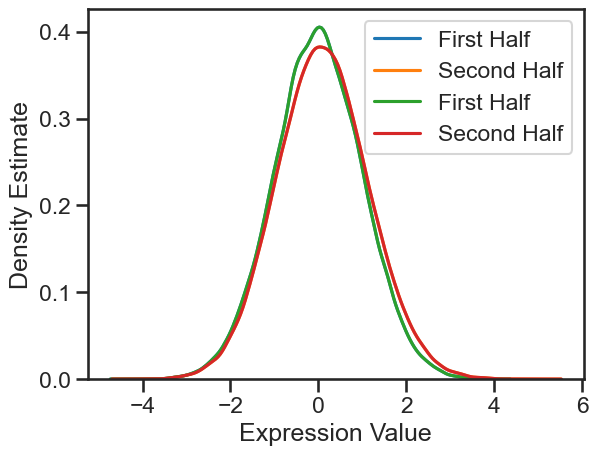

In [12]:
%matplotlib inline 
sns.kdeplot(Y.iloc[range(halfcells), :].values.flatten(), label='First Half')
sns.kdeplot(Y.iloc[halfcells:, :].values.flatten(), label='Second Half')
plt.xlabel('Expression Value')
plt.ylabel('Density Estimate')
plt.legend()
plt.show()

Text(0, 0.5, 'Expression')

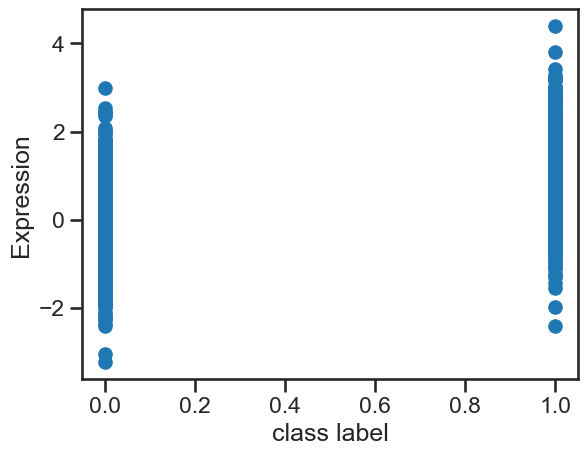

In [13]:
#plot a single gene as a function of class membership
plt.scatter(X['class'],Y[0])
plt.xlabel('class label')
plt.ylabel('Expression')

In [24]:
#Fit regression model
lm=sklearn.linear_model.Ridge()
lm.fit(X,Y)
B=pd.DataFrame(lm.coef_)


,0
0,1.100867
1,0.987179
2,0.907554
3,0.976441
4,1.049788
...,...
195,0.064092
196,-0.071489
197,0.027898
198,0.130688


Text(0, 0.5, 'Coefficient')

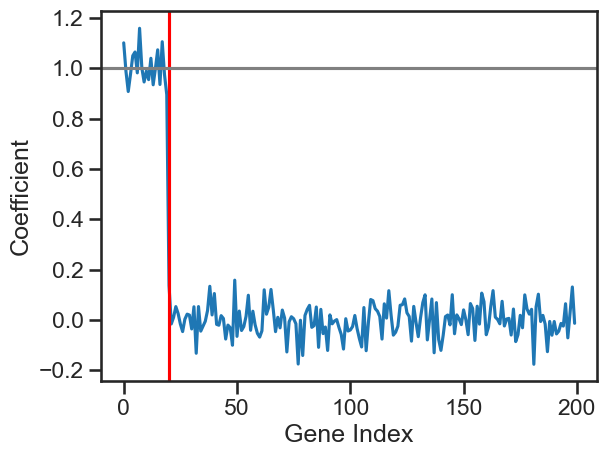

In [15]:
#coefficients for informative subset of genes
plt.plot(B[0])
plt.axvline(ngenes*informativegenes,c='red')
plt.axhline(effectsize,c='gray')
plt.xlabel('Gene Index')
plt.ylabel('Coefficient')

Text(0, 0.5, 'Class Probability')

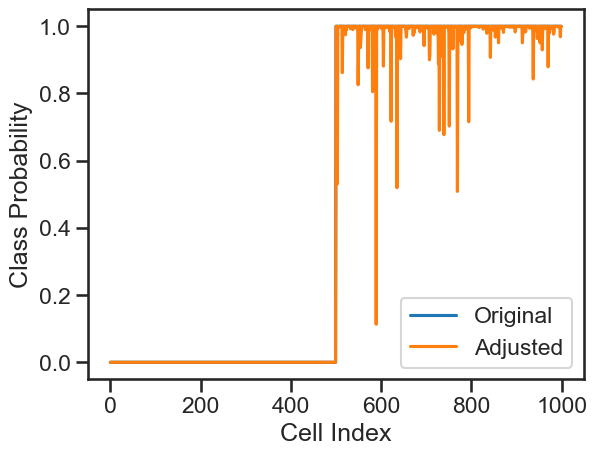

Text(0, 0.5, 'Class Probability')

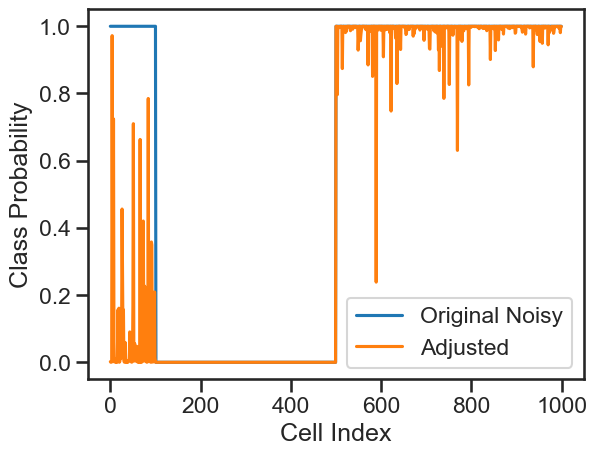

In [19]:

def bayes_cov_col(Y,X,cols,lm):
    """
    @Y    = Expression matrix, cells x x genes, expecting pandas dataframe
    @X    = Covariate matrix, cells x covariates, expecting pandas dataframe
    @cols = The subset of columns that the EM should be performed over, expecting list
    @lm   = linear model object
    """

    #EM iterateit
    Yhat=pd.DataFrame(lm.predict(X))
    Yhat.index=Y.index
    Yhat.columns=Y.columns
    SSE_all=np.square(Y.subtract(Yhat))
    X_adjust=X.copy()


    df_SSE   = []
    df_logit = []

    for curcov in cols:

        curcells=X[X[curcov]>0].index

        if len(curcells)>2:

            X_notcur=X.copy()
            X_notcur[curcov]=[0]*len(X_notcur)

            X_sub=X_notcur.loc[curcells]

            Y_sub=Y.loc[curcells]

            GENE_var=2.0*Y_sub.var(axis=0)
            vargenes=GENE_var[GENE_var>0].index

            Yhat_notcur=pd.DataFrame(lm.predict(X_sub))
            Yhat_notcur.index=Y_sub.index
            Yhat_notcur.columns=Y_sub.columns

            SSE_notcur=np.square(Y_sub.subtract(Yhat_notcur))
            SSE=SSE_all.loc[curcells].subtract(SSE_notcur)
            SSE_sum=SSE.sum(axis=1)

            SSE_transform=SSE.div(GENE_var+0.5)[vargenes].sum(axis=1)
            logitify=np.divide(1.0,1.0+np.exp(SSE_transform))#sum))

            df_SSE.append(SSE_sum)
            df_logit.append(logitify)

            X_adjust[curcov].loc[curcells]=logitify

    return X_adjust

#Adjust covariates based on fitted coefficients
X_adjust=bayes_cov_col(Y,X,['class'],lm)
#Plot original and adjusted covariates
plt.plot(X,label='Original')
plt.plot(X_adjust,label='Adjusted')
plt.legend(loc='lower right')
plt.xlabel('Cell Index')
plt.ylabel('Class Probability')
#Fit regression model on noisy covariates (note how the first ten percent of cells are mostly reclassified as class 0)
lm_noise=sklearn.linear_model.Ridge()
lm_noise.fit(X_noise,Y)
B_noise=pd.DataFrame(lm_noise.coef_)
X_adjust_noise=bayes_cov_col(Y,X_noise,['class'],lm_noise)
plt.plot(X_noise,label='Original Noisy')
plt.plot(X_adjust_noise,label='Adjusted')
plt.legend(loc='lower right')
plt.xlabel('Cell Index')
plt.ylabel('Class Probability')

lm_noise_adjust=sklearn.linear_model.Ridge()
lm_noise_adjust.fit(X_adjust_noise,Y)
B_noise_adjust=pd.DataFrame(lm_noise_adjust.coef_)

#plot coefficients for informative subset of genes
plt.plot(B_noise[0],label='Original')
plt.plot(B_noise_adjust[0],label='Adjusted')
plt.axvline(ngenes*informativegenes,c='red')
plt.axhline(effectsize,c='gray')
plt.legend(loc='upper right')
plt.xlabel('Gene Index')
plt.ylabel('Coefficient')

Text(0, 0.5, 'Coefficient')

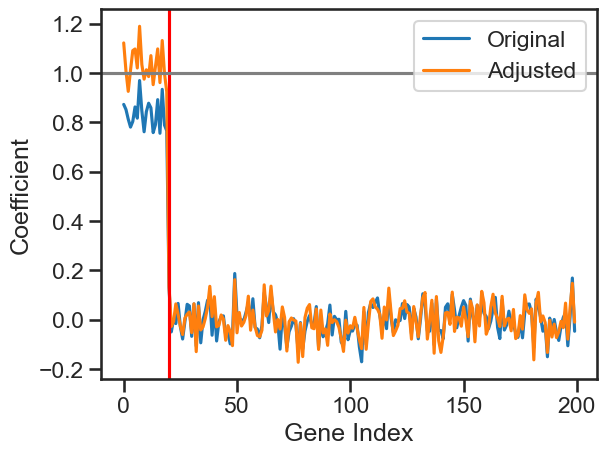

In [21]:
#plot coefficients for informative subset of genes
plt.plot(B_noise[0],label='Original')
plt.plot(B_noise_adjust[0],label='Adjusted')
plt.axvline(ngenes*informativegenes,c='red')
plt.axhline(effectsize,c='gray')
plt.legend(loc='upper right')
plt.xlabel('Gene Index')
plt.ylabel('Coefficient')

In [31]:
# Read in samples
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer

# Here psi is going to be Y the response variable.
psi = pd.read_csv('~/Dropbox (Harvard University)/02Splicing/latest/df_all_samples_mat_aligned.csv', index_col=0)
# X is going to be gex.
gex = pd.read_csv("~/Dropbox (Harvard University)/02Splicing/latest/df_gex_mat_aligned.csv", index_col = 0)

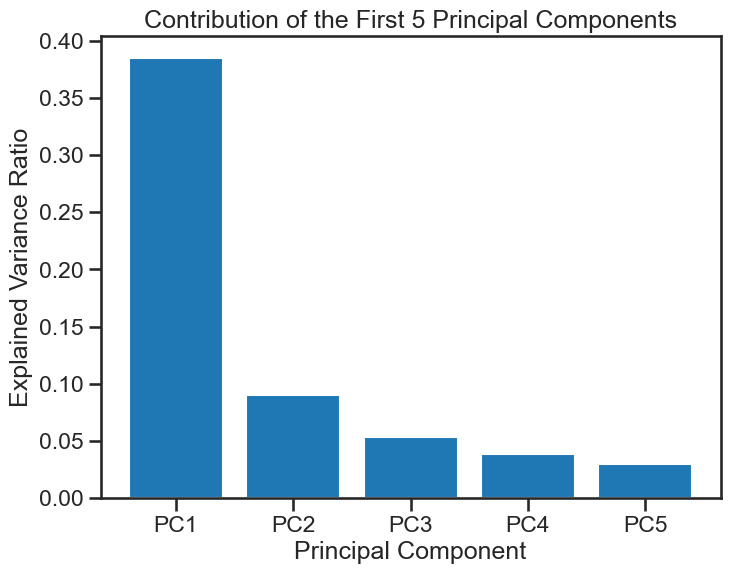

ENSG00000079156.17;OSBPL6;chr2-178324176-178324269-178306029-178306286-178328255-178328378      0.012636
ENSG00000110074.11;FOXRED1;chr11-126272968-126273079-126270944-126271657-126273335-126273454    0.012500
ENSG00000073584.20;SMARCE1;chr17-40642454-40642559-40637095-40637572-40645575-40645619          0.012217
ENSG00000108395.14;TRIM37;chr17-59104292-59104394-59091299-59091340-59106440-59106459           0.012180
ENSG00000196510.14;ANAPC7;chr12-110388511-110388623-110387738-110387892-110395100-110395220     0.012071
Name: PC1, dtype: float64


In [42]:
# perform PCA on psi to dimensionality reduction. 
# Here psi is going to be Y the response variable.
psi = pd.read_csv('~/Dropbox (Harvard University)/02Splicing/latest/df_all_samples_mat_aligned.csv', index_col=0)
# X is going to be gex.
gex = pd.read_csv("~/Dropbox (Harvard University)/02Splicing/latest/df_gex_mat_aligned.csv", index_col = 0)
# Perform PCA, keeping only the first 5 principal components
# Drop columns that have all NaN values
psi = psi.dropna(axis=1, how='all')

# Impute missing values using the mean of each column
imputer = SimpleImputer(strategy='mean')
psi_imputed = imputer.fit_transform(psi)

# Perform PCA, keeping only the first 5 principal components
pca = PCA(n_components=5)
pca.fit(psi_imputed)

# Get the weights (loadings) of the first 5 principal components
weights = pca.components_

# Calculate the explained variance ratio for the first 5 principal components
explained_variance = pca.explained_variance_ratio_

# Plot the contributions of the first 5 principal components
plt.figure(figsize=(8, 6))
x = np.arange(1, 6)
plt.bar(x, explained_variance, tick_label=['PC1', 'PC2', 'PC3', 'PC4', 'PC5'])
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance Ratio')
plt.title('Contribution of the First 5 Principal Components')
plt.show()

# Create DataFrame for weights (loadings)
weights_df = pd.DataFrame(weights, columns=psi.columns, index=[f'PC{i}' for i in range(1, 6)])

# Extract the loadings for PC1
pc1_loadings = weights_df.loc['PC1']

# Find the variables with the highest absolute contribution to PC1
top_contributors = pc1_loadings.abs().sort_values(ascending=False)

# Display the top contributing variables to PC1
print(top_contributors.head())

             PC1       PC2        PC3       PC4       PC5
769P    3.512463 -2.298384  12.412434  0.440518 -1.085197
786O  -12.685887  0.198655  -2.156923 -2.163928 -1.535636
8MGBA  -2.445372  5.909401  -0.788840 -2.308089  4.276129
A375   26.272174 -9.722026  -1.077622 -5.797035  5.218774
ACHN  -11.721772  0.039948  -4.634597 -3.446937 -0.671279


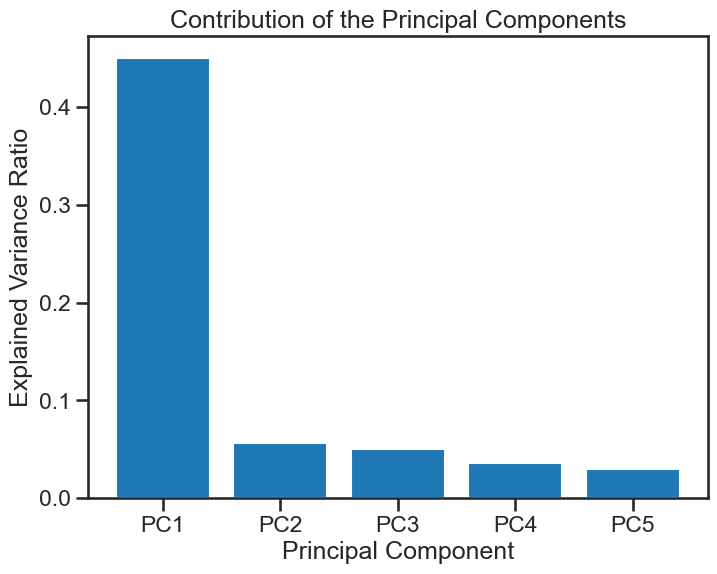

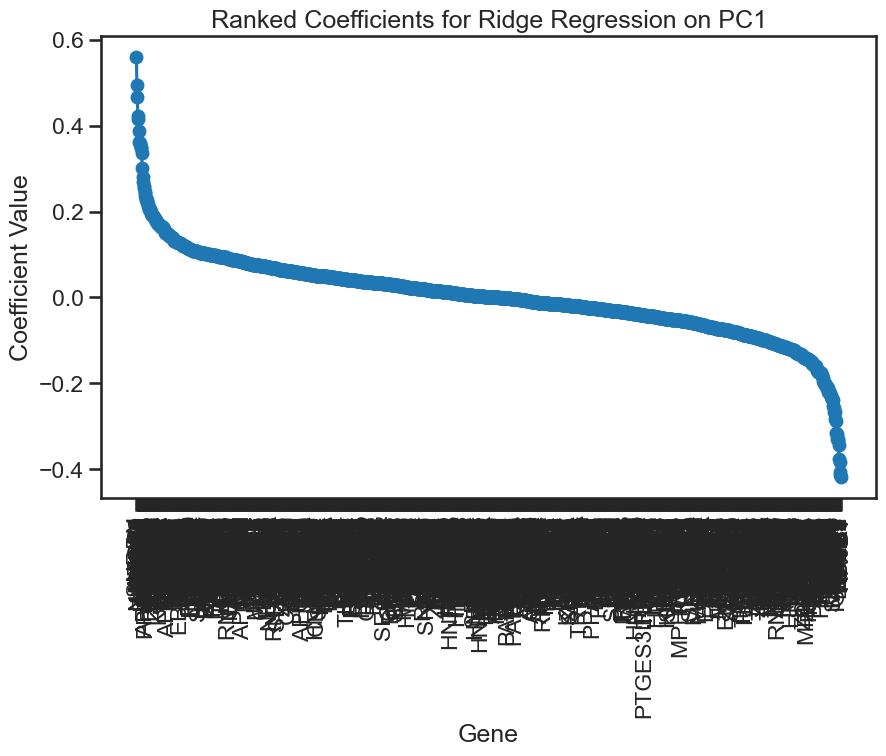

Top 20 Genes with Highest Coefficients:
          Gene  Coefficient
573      SNRPN     0.560741
1290    NANOS1     0.494905
275      MYEF2     0.465736
942      AZGP1     0.422121
1276    HEXIM1     0.416486
543     MIF4GD     0.388155
1035     LARP6     0.362881
456      PRDX1     0.359285
1117     ISG20     0.357268
8         YBX2     0.350508
715      SMAD6     0.348983
684    IGF2BP3     0.336095
1187     RPP25     0.302392
881    ZFP36L2     0.281127
1065    HEXIM2     0.269294
263      ESRP2     0.258696
1322    ADARB1     0.253919
661      DZIP1     0.244741
359   PPARGC1A     0.243715
1200     MKRN3     0.235132

Top 20 Genes with Lowest Coefficients:
         Gene  Coefficient
1201     PLD6    -0.236529
511    ZC3H13    -0.237428
174    MRPS33    -0.239107
46      CELF2    -0.252788
74      TNPO3    -0.257773
239    SAMHD1    -0.266958
665      OASL    -0.267462
1269    IFIT1    -0.283099
668     KHDC1    -0.288564
292     NOVA2    -0.317297
931   IGF2BP1    -0.317360
1435    

In [120]:
# perform PCA on psi to dimensionality reduction. 
# Here psi is going to be Y the response variable.
psi = pd.read_csv('~/Dropbox (Harvard University)/02Splicing/latest/df_all_samples_mat_aligned.csv', index_col=0)
# X is going to be gex.
gex = pd.read_csv("~/Dropbox (Harvard University)/02Splicing/latest/df_gex_mat_aligned.csv", index_col = 0)
# Perform PCA, keeping only the first 5 principal components
# Drop columns that have all NaN values
psi = psi.dropna(axis=1, how='all')

# Impute missing values using the mean of each column
imputer = SimpleImputer(strategy='mean')
psi_imputed = imputer.fit_transform(psi)
# Perform PCA, keeping only the first 5 principal components
n_components = 5  # Adjust this number as needed based on how much dimensionality reduction you want
pca = PCA(n_components=n_components)
pca.fit(psi_imputed)

# Get the transformed data (dimensionality reduced matrix)
psi_transformed = pca.transform(psi_imputed)

# Convert the transformed data to a DataFrame for easier handling
psi_transformed_df = pd.DataFrame(psi_transformed, index=psi.index, columns=[f'PC{i+1}' for i in range(n_components)])

# Display the first few rows of the transformed DataFrame
print(psi_transformed_df.head())

# Plot the contributions of the first 5 principal components
explained_variance = pca.explained_variance_ratio_
plt.figure(figsize=(8, 6))
x = np.arange(1, n_components + 1)
plt.bar(x, explained_variance, tick_label=[f'PC{i}' for i in range(1, n_components + 1)])
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance Ratio')
plt.title('Contribution of the Principal Components')
plt.show()

#Fit regression model
lm=sklearn.linear_model.Ridge()
# X is gex
# Y is psi_transformed_df
lm.fit(gex,psi_transformed_df["PC1"])
# lm.fit(X,Y)
B=pd.DataFrame(lm.coef_)
B

# Get coefficients and add back gene names
coefficients = lm.coef_
gene_names = gex.columns
coefficients_df = pd.DataFrame({'Gene': gene_names, 'Coefficient': coefficients})

# Rank coefficients
coefficients_df_sorted = coefficients_df.sort_values(by='Coefficient', ascending=False)

# Plot the ranked coefficients
plt.figure(figsize=(10, 6))
plt.plot(coefficients_df_sorted['Gene'], coefficients_df_sorted['Coefficient'], marker='o')
plt.xticks(rotation=90)
plt.xlabel('Gene')
plt.ylabel('Coefficient Value')
plt.title('Ranked Coefficients for Ridge Regression on PC1')
plt.show()

# Identify genes with the highest and lowest coefficients
top_genes = coefficients_df_sorted.head(20)
bottom_genes = coefficients_df_sorted.tail(20)

print("Top 20 Genes with Highest Coefficients:")
print(top_genes)

print("\nTop 20 Genes with Lowest Coefficients:")
print(bottom_genes)

# If we were to look at all 5 PCs

In [6]:
# Import necessary libraries
import pandas as pd
from sklearn.impute import SimpleImputer
from sklearn.decomposition import PCA
from sklearn import linear_model
import matplotlib.pyplot as plt

# Load the data
psi = pd.read_csv('~/Dropbox (Harvard University)/02Splicing/latest/df_all_samples_mat_aligned.csv', index_col=0)
gex = pd.read_csv('~/Dropbox (Harvard University)/02Splicing/latest/df_gex_mat_aligned.csv', index_col=0)

# Drop columns that have all NaN values
psi = psi.dropna(axis=1, how='all')

# Impute missing values using the mean of each column
imputer = SimpleImputer(strategy='mean')
psi_imputed = imputer.fit_transform(psi)

# Perform PCA, keeping only the first 5 principal components
n_components = 5
pca = PCA(n_components=n_components)
pca.fit(psi_imputed)

# Get the transformed data (dimensionality reduced matrix)
psi_transformed = pca.transform(psi_imputed)
psi_transformed_df = pd.DataFrame(psi_transformed, index=psi.index, columns=[f'PC{i+1}' for i in range(n_components)])

# Fit Ridge regression model using gex (X) to predict all principal components (Y)
lm = linear_model.Ridge()
lm.fit(gex, psi_transformed_df)

# Get coefficients and add back gene names
coefficients = lm.coef_  # This will be a 2D array with shape (n_components, n_features)
gene_names = gex.columns

# Create a DataFrame to hold the coefficients for each PC
coefficients_df = pd.DataFrame(coefficients.T, index=gene_names, columns=[f'PC{i+1}' for i in range(n_components)])

# Rank genes by coefficients from big to small for each principal component
ranked_genes = coefficients_df.apply(lambda x: x.sort_values(ascending=False).index)

print("Ranked Genes by Coefficients for each PC:")
print(ranked_genes)

# Optionally, save the ranked genes to a CSV file
ranked_genes.to_csv('~/Dropbox (Harvard University)/02Splicing/ridge_PSI_ranked_genes_by_coefficients.csv')


Ranked Genes by Coefficients for each PC:
            PC1       PC2      PC3       PC4      PC5
LAS1L     SNRPN      OAS2    DDX43      DAZ3  IGF2BP1
RBM5     NANOS1    LIN28A    U2AF1      DAZ4    SNRPN
RBM6      MYEF2    SAMHD1    CPEB1      DAZ1    TDRD9
UPF1      AZGP1    EEF1A2    MCTS1    RBPMS2  IGF2BP3
POLR2J   HEXIM1  C11orf68  ZC3H12A      OASL    AZGP1
...         ...       ...      ...       ...      ...
DDX52    ELAVL2     C1QBP    ISG20     IFIT5   EIF4E3
MRM1      CPEB1    RPS27L    RPP25     SRRM3    KHDC1
MRPL45    RBM20    LIN28B     NPM2  ARHGEF28    NR0B1
RPS4Y2    NOVA1     ISG20    PEG10    SAMHD1    PRDX1
POLR2J3   NR0B1   KHDRBS3  ZCCHC24    EEF1A2   RNASE4

[1473 rows x 5 columns]


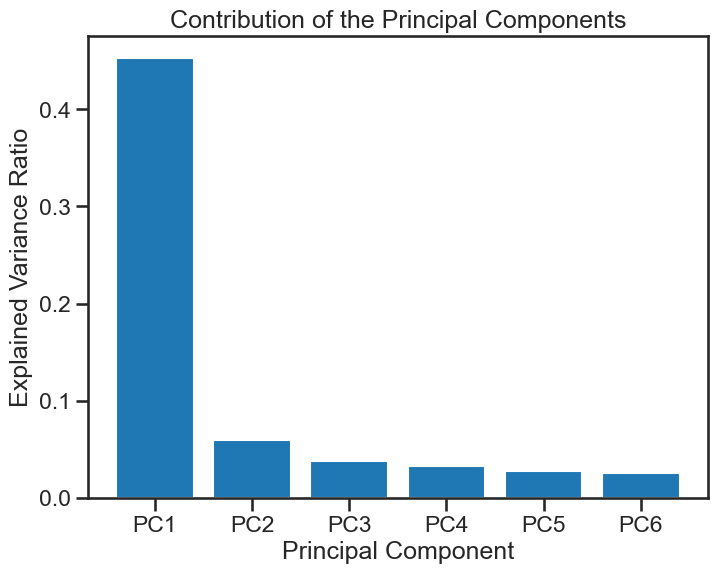

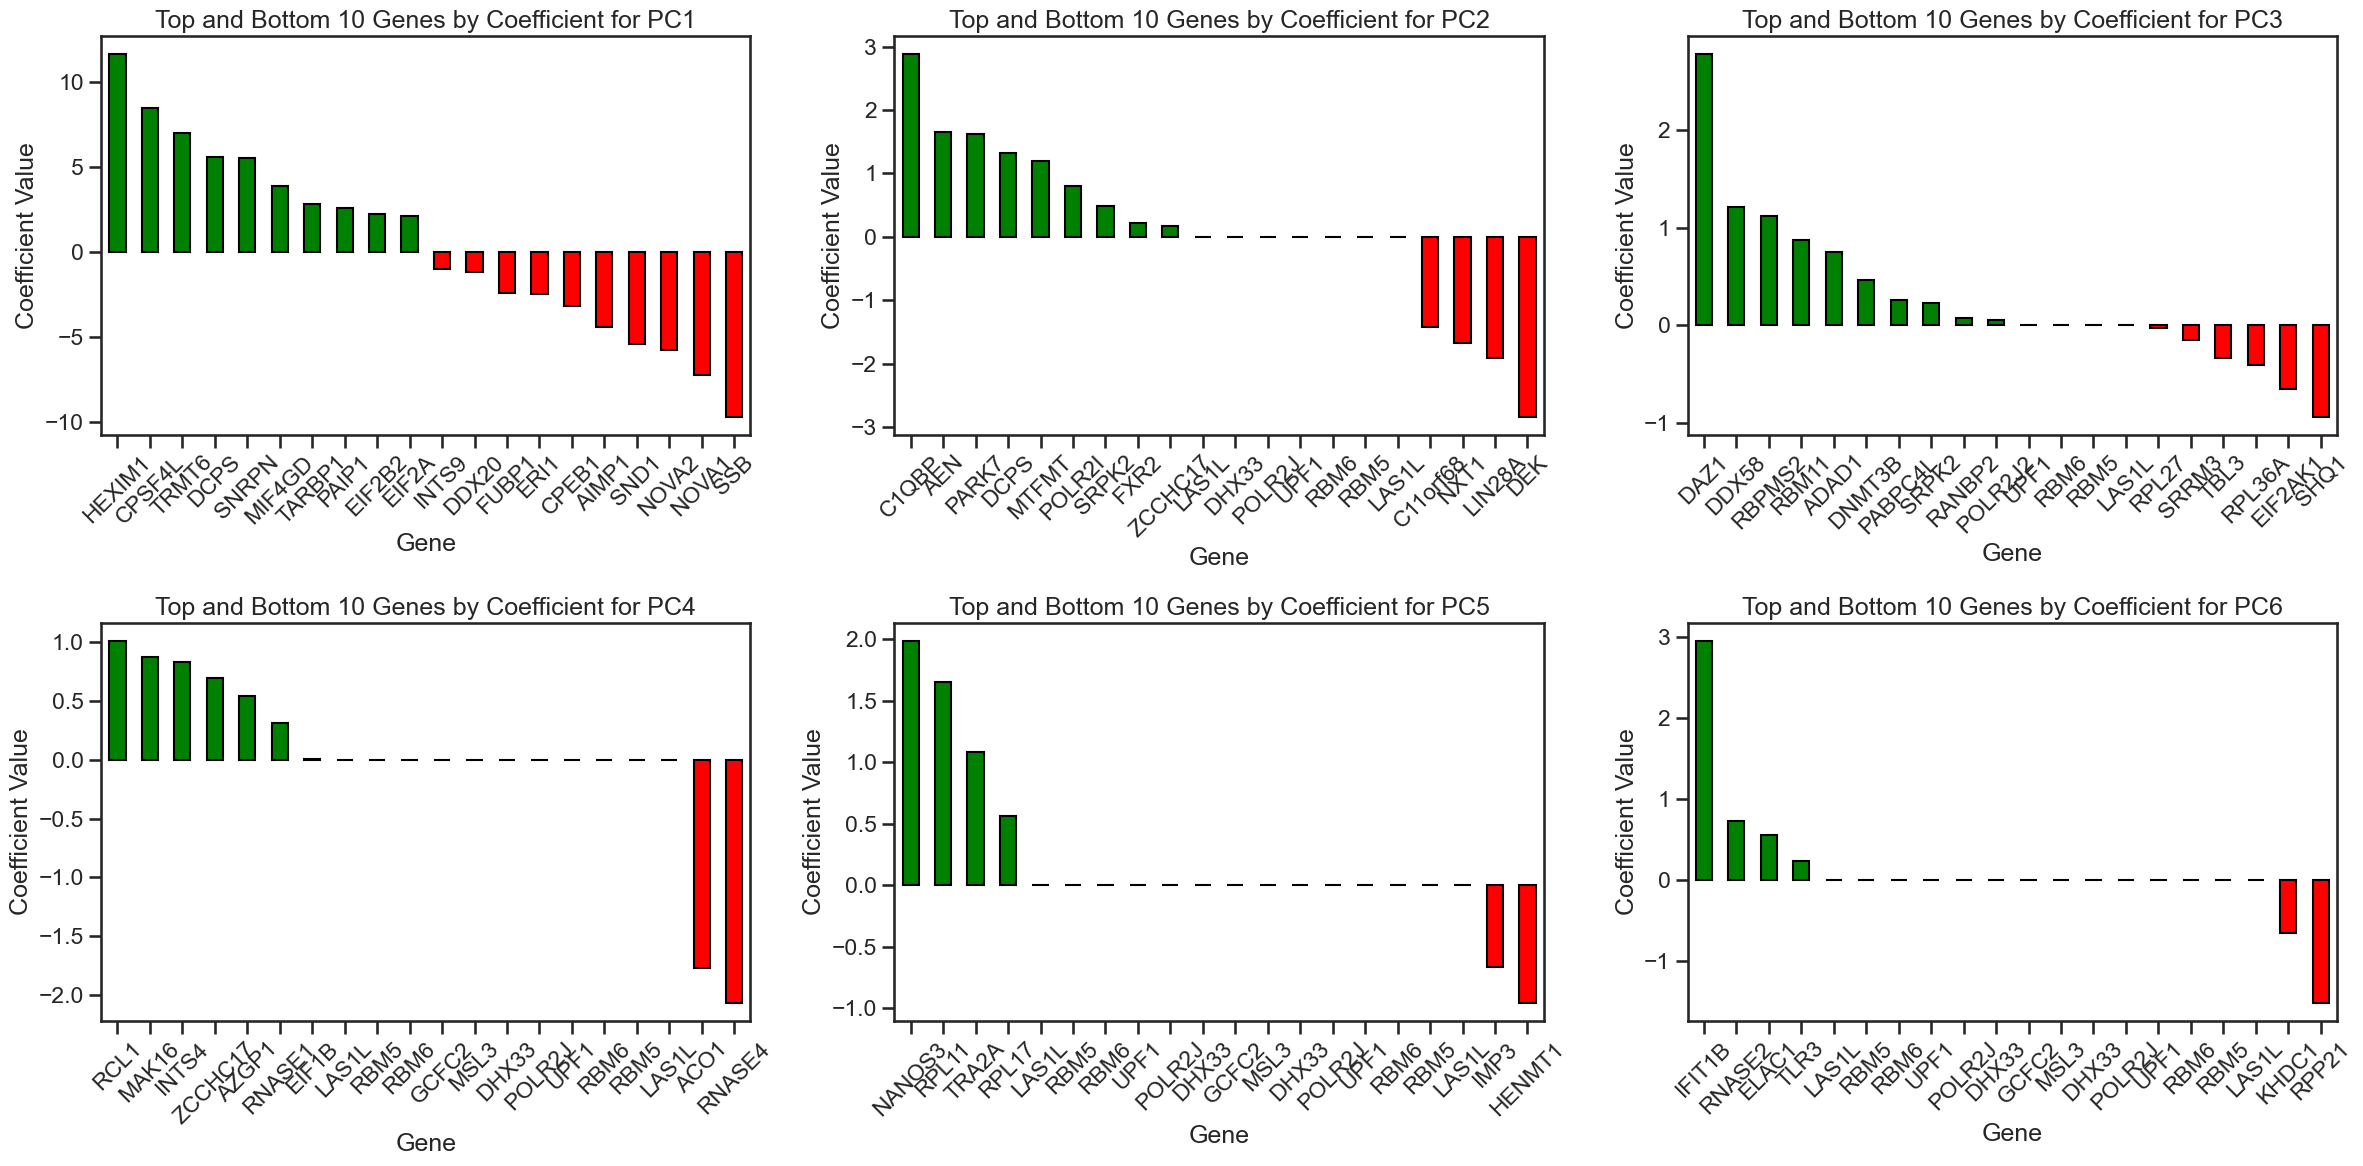

In [51]:
# Import necessary libraries
import pandas as pd
from sklearn.impute import SimpleImputer
from sklearn.decomposition import PCA
from sklearn import linear_model
import matplotlib.pyplot as plt
import numpy as np

# Load the data
psi = pd.read_csv('~/Dropbox (Harvard University)/02Splicing/latest/df_all_samples_mat_aligned.csv', index_col=0)
# psi = pd.read_csv('~/Dropbox (Harvard University)/02Splicing/latest/df_all_samples_mat_aligned_binarized.csv', index_col=0)
gex = pd.read_csv('~/Dropbox (Harvard University)/02Splicing/latest/df_gex_mat_aligned.csv', index_col=0)

# Drop columns that have all NaN values
psi = psi.dropna(axis=1, how='all')

# Impute missing values using the mean of each column
imputer = SimpleImputer(strategy='mean')
psi_imputed = imputer.fit_transform(psi)

# Perform PCA, keeping only the first 5 principal components
n_components = 6
pca = PCA(n_components=n_components)
pca.fit(psi_imputed)

# Get the transformed data (dimensionality reduced matrix)
psi_transformed = pca.transform(psi_imputed)
psi_transformed_df = pd.DataFrame(psi_transformed, index=psi.index, columns=[f'PC{i+1}' for i in range(n_components)])

# Plot the contributions of the first 5 principal components
explained_variance = pca.explained_variance_ratio_
plt.figure(figsize=(8, 6))
x = np.arange(1, n_components + 1)
plt.bar(x, explained_variance, tick_label=[f'PC{i}' for i in range(1, n_components + 1)])
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance Ratio')
plt.title('Contribution of the Principal Components')

# Save the plot as a PDF
output_path_variance = '/Users/dawnxi/Dropbox (Harvard University)/02Splicing/SplicingManuscript/figure_outputs/contribution_of_principal_components.pdf'
plt.savefig(output_path_variance, format='pdf')

plt.show()

# Normalize gex by column so it scales to between 0 and 1
gex_normalized = (gex - gex.min()) / (gex.max() - gex.min())
# remove the 3 genes with nan values
gex_normalized = gex_normalized.dropna(axis=1)

# Fit Ridge regression model using gex (X) to predict all principal components (Y)
lm = linear_model.Lasso(alpha=0.2)

lm.fit(gex_normalized, psi_transformed_df)

# Get coefficients and add back gene names
coefficients = lm.coef_  # This will be a 2D array with shape (n_components, n_features)
gene_names = gex_normalized.columns

# Create a DataFrame to hold the coefficients for each PC
coefficients_df = pd.DataFrame(coefficients.T, index=gene_names, columns=[f'PC{i+1}' for i in range(n_components)])

coefficients_df.to_csv('~/Dropbox (Harvard University)/02Splicing/ridge_PSI_coefficients.csv')

# Create subplots with 3 plots per row
fig, axes = plt.subplots(2, 3, figsize=(24, 12))  # 2 rows, 3 columns for subplots

# Flatten axes array for easy iteration
axes = axes.flatten()

for i, pc in enumerate(coefficients_df.columns):
    # Get the top 10 and bottom 10 genes for the current PC
    top_genes = coefficients_df[pc].nlargest(10)
    bottom_genes = coefficients_df[pc].nsmallest(10)
    
    # Concatenate top and bottom genes into a single series, maintaining order
    selected_genes = pd.concat([top_genes, bottom_genes[::-1]])
    
    # Plot the selected genes on the corresponding subplot
    ax = axes[i]
    selected_genes.plot(kind='bar', ax=ax, color=['green' if x > 0 else 'red' for x in selected_genes], edgecolor='black')
    ax.set_title(f'Top and Bottom 10 Genes by Coefficient for {pc}')
    ax.set_ylabel('Coefficient Value')
    ax.set_xlabel('Gene')
    ax.tick_params(axis='x', rotation=45)

# Remove any unused subplots (in case n_components < number of subplots)
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

# Adjust layout
plt.tight_layout()

# Save the subplots as a PDF
output_path_coefficients = '/Users/dawnxi/Dropbox (Harvard University)/02Splicing/SplicingManuscript/figure_outputs/top_bottom_genes_by_coefficient.pdf'
plt.savefig(output_path_coefficients, format='pdf')


plt.show()




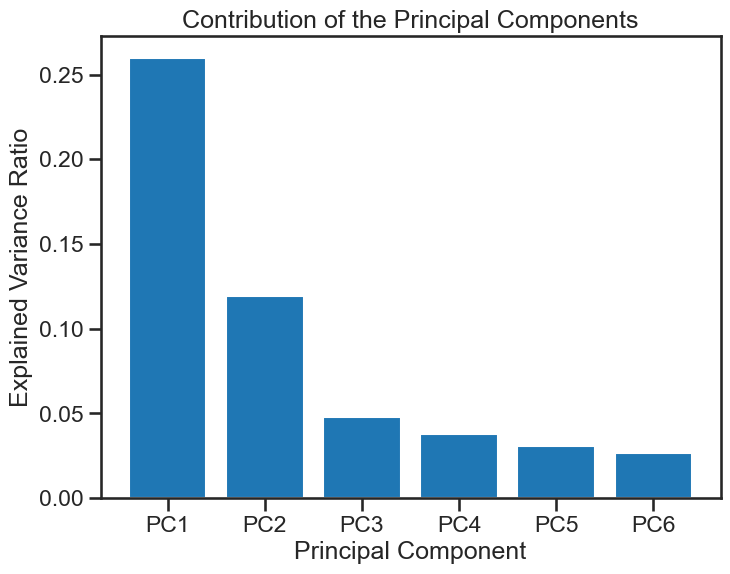

ValueError: For multi-task outputs, use MultiTaskLassoCV

In [48]:
# Import necessary libraries
import pandas as pd
from sklearn.impute import SimpleImputer
from sklearn.decomposition import PCA
from sklearn.linear_model import LassoCV
import matplotlib.pyplot as plt
import numpy as np

# Load the data
psi = pd.read_csv('~/Dropbox (Harvard University)/02Splicing/latest/df_all_samples_mat_aligned_binarized.csv', index_col=0)
gex = pd.read_csv('~/Dropbox (Harvard University)/02Splicing/latest/df_gex_mat_aligned.csv', index_col=0)

# Drop columns that have all NaN values
psi = psi.dropna(axis=1, how='all')

# Impute missing values using the mean of each column
imputer = SimpleImputer(strategy='mean')
psi_imputed = imputer.fit_transform(psi)

# Perform PCA, keeping only the first 6 principal components
n_components = 6
pca = PCA(n_components=n_components)
pca.fit(psi_imputed)

# Get the transformed data (dimensionality reduced matrix)
psi_transformed = pca.transform(psi_imputed)
psi_transformed_df = pd.DataFrame(psi_transformed, index=psi.index, columns=[f'PC{i+1}' for i in range(n_components)])

# Plot the contributions of the first 6 principal components
explained_variance = pca.explained_variance_ratio_
plt.figure(figsize=(8, 6))
x = np.arange(1, n_components + 1)
plt.bar(x, explained_variance, tick_label=[f'PC{i}' for i in range(1, n_components + 1)])
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance Ratio')
plt.title('Contribution of the Principal Components')

# Save the plot as a PDF
# output_path_variance = '~/Dropbox (Harvard University)/02Splicing/SplicingManuscript/figure_outputs/contribution_of_principal_components.pdf'
# plt.savefig(output_path_variance, format='pdf')

plt.show()

# Normalize gex by column so it scales to between 0 and 1
gex_normalized = (gex - gex.min()) / (gex.max() - gex.min())
# Remove the 3 genes with NaN values
gex_normalized = gex_normalized.dropna(axis=1)

# Perform LassoCV to find the best alpha with cross-validation
lasso_cv = LassoCV(cv=5, random_state=42).fit(gex_normalized, psi_transformed_df)

# Get the optimal alpha
optimal_alpha = lasso_cv.alpha_
print(f"Optimal alpha: {optimal_alpha}")

# Extract coefficients and match them with gene names
coefficients = lasso_cv.coef_  # Shape: (n_components, n_features)
gene_names = gex_normalized.columns

# Loop through each principal component to extract coefficients and display top genes
for i in range(coefficients.shape[0]):
    pc_name = f'PC{i+1}'
    pc_coefficients = coefficients[i]  # Extract coefficients for the current PC
    
    # Check if the length of gene names matches the number of coefficients
    if len(gene_names) == len(pc_coefficients):
        # Create a DataFrame to hold the coefficients and gene names for the current PC
        coefficients_df = pd.DataFrame({'Gene': gene_names, 'Coefficient': pc_coefficients})
        
        # Sort coefficients and display top 10 genes
        coefficients_df_sorted = coefficients_df.sort_values(by='Coefficient', ascending=False)
        print(f"Top 10 genes for {pc_name}:")
        print(coefficients_df_sorted.head(10))
        
        # Save the sorted coefficients as CSV for each PC
        coefficients_df_sorted.to_csv(f'~/Dropbox (Harvard University)/02Splicing/lasso_PSI_coefficients_{pc_name}.csv', index=False)
    else:
        print(f"Mismatch in lengths: {len(gene_names)} gene names and {len(pc_coefficients)} coefficients for {pc_name}")

# Create subplots to visualize top and bottom genes by coefficients for each PC
fig, axes = plt.subplots(2, 3, figsize=(24, 12))  # 2 rows, 3 columns for subplots
axes = axes.flatten()

for i, pc in enumerate([f'PC{i+1}' for i in range(n_components)]):
    pc_coefficients = coefficients[i]
    
    # Create a DataFrame for top 10 and bottom 10 genes
    coefficients_df = pd.DataFrame({'Gene': gene_names, 'Coefficient': pc_coefficients})
    top_genes = coefficients_df.nlargest(10, 'Coefficient')
    bottom_genes = coefficients_df.nsmallest(10, 'Coefficient')
    
    # Combine top and bottom genes
    selected_genes = pd.concat([top_genes, bottom_genes[::-1]])
    
    # Plot the selected genes
    ax = axes[i]
    selected_genes.plot(kind='bar', ax=ax, x='Gene', y='Coefficient', color=['green' if x > 0 else 'red' for x in selected_genes['Coefficient']], edgecolor='black')
    ax.set_title(f'Top and Bottom 10 Genes by Coefficient for {pc}')
    ax.set_ylabel('Coefficient Value')
    ax.tick_params(axis='x', rotation=45)

# Remove any unused subplots (if n_components < 6)
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()

# Save the subplots as a PDF
output_path_coefficients = '~/Dropbox (Harvard University)/02Splicing/SplicingManuscript/figure_outputs/top_bottom_genes_by_coefficient.pdf'
plt.savefig(output_path_coefficients, format='pdf')

plt.show()


In [39]:
# Get coefficients and add back gene names
coefficients = lm.coef_[0]  # Assuming you are plotting for PC1, hence using the first row of coefficients
gene_names = gex.columns
coefficients_df = pd.DataFrame({'Gene': gene_names, 'Coefficient': coefficients})

# Rank coefficients
coefficients_df_sorted = coefficients_df.sort_values(by='Coefficient', ascending=False)

# Plot the ranked coefficients using a bar plot
plt.figure(figsize=(8, 6))
plt.scatter(coefficients_df_sorted['Gene'], coefficients_df_sorted['Coefficient'], color='skyblue')
# plt.xticks(rotation=90)
plt.xticks([])  # Remove x-axis labels
plt.xlabel('Gene')
plt.ylabel('Coefficient Value')
plt.title('Ranked Coefficients for Ridge Regression on PC1')
plt.tight_layout()
# Save the plot as a PDF
output_path = '/Users/dawnxi/Dropbox (Harvard University)/02Splicing/SplicingManuscript/figure_outputs/ranked_coefficients_pc1.pdf'
plt.savefig(output_path, format='pdf')

plt.show()
# # Identify genes with the highest and lowest coefficients
# top_genes = coefficients_df_sorted.head(20)
# bottom_genes = coefficients_df_sorted.tail(20)

# print("Top 20 Genes with Highest Coefficients:")
# print(top_genes)

# print("\nTop 20 Genes with Lowest Coefficients:")
# print(bottom_genes)


ValueError: All arrays must be of the same length

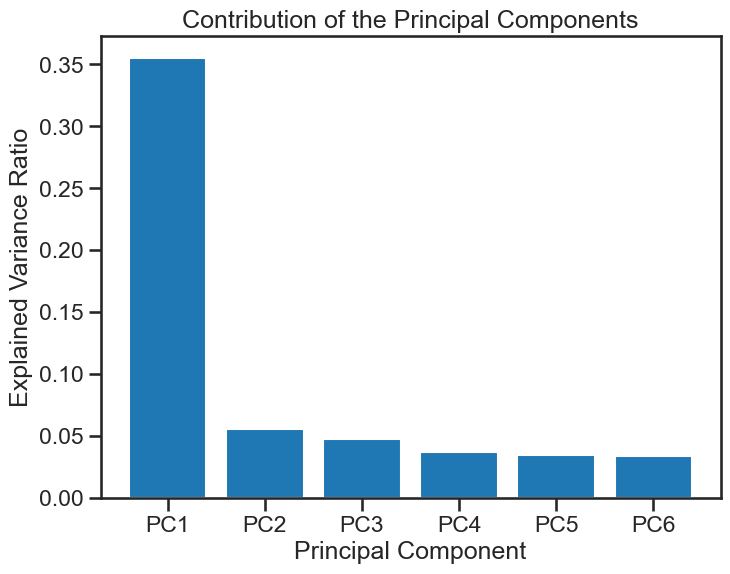

Chosen alpha: 1.0


ValueError: Shape of passed values is (1470, 6), indices imply (1473, 6)

In [40]:
# Import necessary libraries
import pandas as pd
from sklearn.impute import SimpleImputer
from sklearn.decomposition import PCA
from sklearn.linear_model import RidgeCV
from sklearn.model_selection import RepeatedKFold
import matplotlib.pyplot as plt
import numpy as np

# Load the data
psi = pd.read_csv('~/Dropbox (Harvard University)/02Splicing/latest/df_all_samples_mat_aligned.csv', index_col=0)
gex = pd.read_csv('~/Dropbox (Harvard University)/02Splicing/latest/df_gex_mat_aligned.csv', index_col=0)

# Drop columns that have all NaN values
psi = psi.dropna(axis=1, how='all')

# Impute missing values using the mean of each column
imputer = SimpleImputer(strategy='mean')
psi_imputed = imputer.fit_transform(psi)

# Perform PCA, keeping only the first 5 principal components
n_components = 6
pca = PCA(n_components=n_components)
pca.fit(psi_imputed)

# Get the transformed data (dimensionality reduced matrix)
psi_transformed = pca.transform(psi_imputed)
psi_transformed_df = pd.DataFrame(psi_transformed, index=psi.index, columns=[f'PC{i+1}' for i in range(n_components)])

# Plot the contributions of the first 5 principal components
explained_variance = pca.explained_variance_ratio_
plt.figure(figsize=(8, 6))
x = np.arange(1, n_components + 1)
plt.bar(x, explained_variance, tick_label=[f'PC{i}' for i in range(1, n_components + 1)])
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance Ratio')
plt.title('Contribution of the Principal Components')
plt.show()

# Normalize gex by column so it scales to between 0 and 1
gex_normalized = (gex - gex.min()) / (gex.max() - gex.min())
# remove the 3 genes with nan values
gex_normalized = gex_normalized.dropna(axis=1)

# Define model evaluation method
cv = RepeatedKFold(n_splits=10, n_repeats=3, random_state=1)

# Define model with cross-validation to select best alpha
alphas = np.arange(0.01, 1.01, 0.01)  # Adjust alpha range as needed
ridge_cv_model = RidgeCV(alphas=alphas, cv=cv, scoring='neg_mean_absolute_error')

# Fit Ridge regression model using gex (X) to predict all principal components (Y)
ridge_cv_model.fit(gex_normalized, psi_transformed_df)

# Get the chosen alpha
best_alpha = ridge_cv_model.alpha_
print(f'Chosen alpha: {best_alpha}')

# Get coefficients and add back gene names
coefficients = ridge_cv_model.coef_  # This will be a 2D array with shape (n_components, n_features)
gene_names = gex.columns

# Create a DataFrame to hold the coefficients for each PC
coefficients_df = pd.DataFrame(coefficients.T, index=gene_names, columns=[f'PC{i+1}' for i in range(n_components)])

# Save coefficients to a CSV file
coefficients_df.to_csv('~/Dropbox (Harvard University)/02Splicing/ridge_PSI_coefficients.csv')

# Create subplots with 3 plots per row
fig, axes = plt.subplots(2, 3, figsize=(24, 12))  # 2 rows, 3 columns for subplots

# Flatten axes array for easy iteration
axes = axes.flatten()

for i, pc in enumerate(coefficients_df.columns):
    # Get the top 10 and bottom 10 genes for the current PC
    top_genes = coefficients_df[pc].nlargest(10)
    bottom_genes = coefficients_df[pc].nsmallest(10)
    
    # Concatenate top and bottom genes into a single series, maintaining order
    selected_genes = pd.concat([top_genes, bottom_genes[::-1]])
    
    # Plot the selected genes on the corresponding subplot
    ax = axes[i]
    selected_genes.plot(kind='bar', ax=ax, color=['green' if x > 0 else 'red' for x in selected_genes], edgecolor='black')
    ax.set_title(f'Top and Bottom 10 Genes by Coefficient for {pc}')
    ax.set_ylabel('Coefficient Value')
    ax.set_xlabel('Gene')
    ax.tick_params(axis='x', rotation=45)

# Remove any unused subplots (in case n_components < number of subplots)
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

# Adjust layout
plt.tight_layout()
plt.show()
